In [16]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl

In [17]:
atlas = 'Nettekoven2024'
rois  = gl.rois[atlas]

In [18]:
segment = 'GM'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')


# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str.lower().str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str.lower().str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str.lower().str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str.lower().str[2]

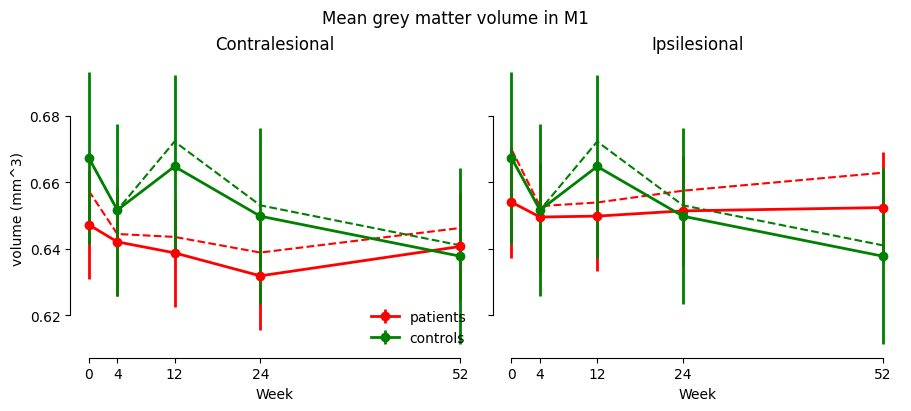

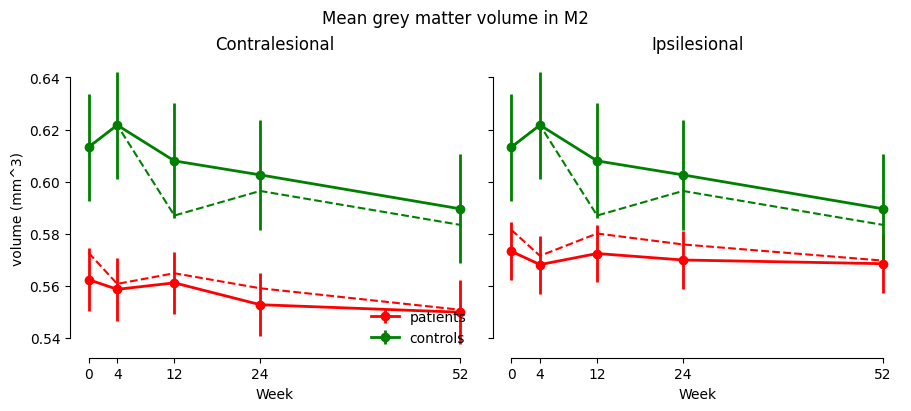

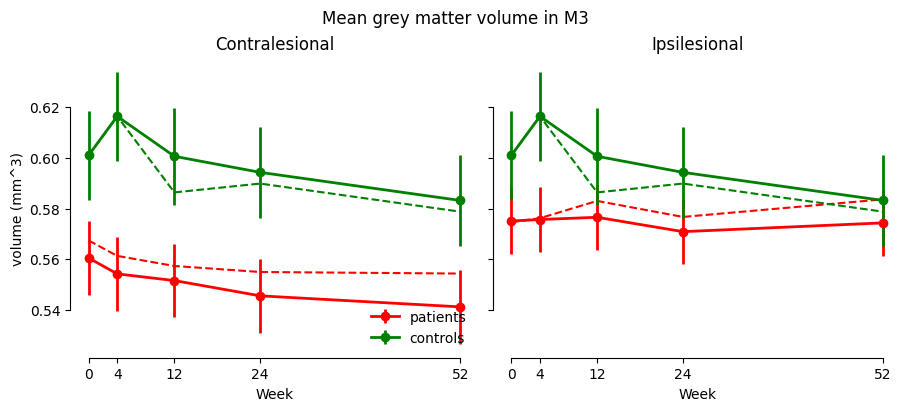

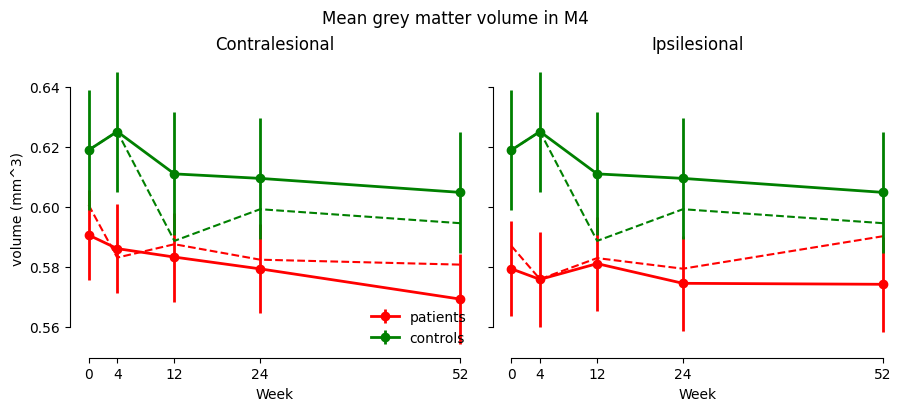

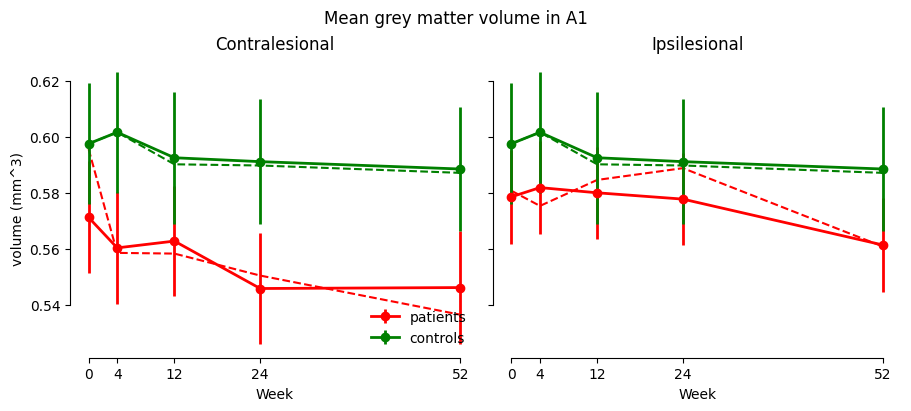

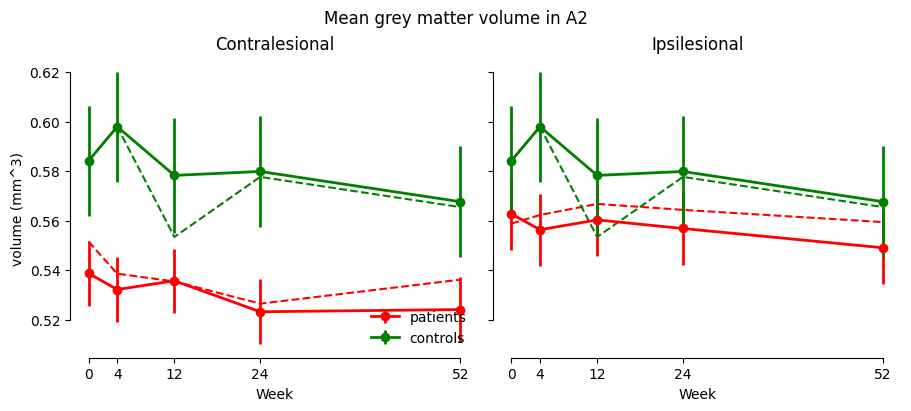

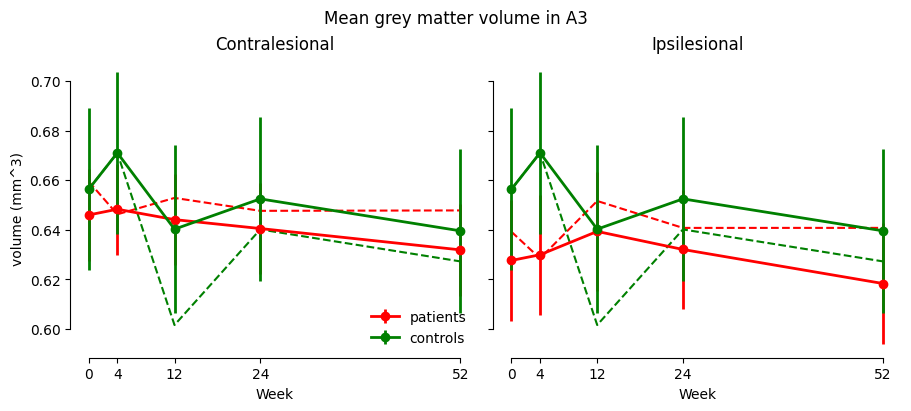

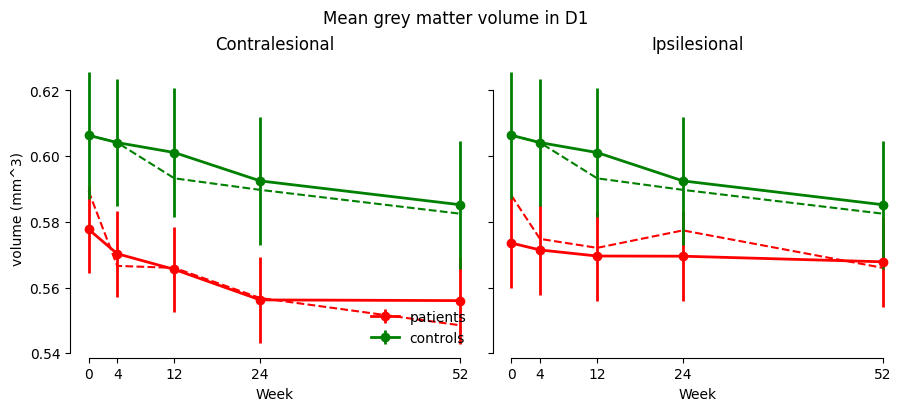

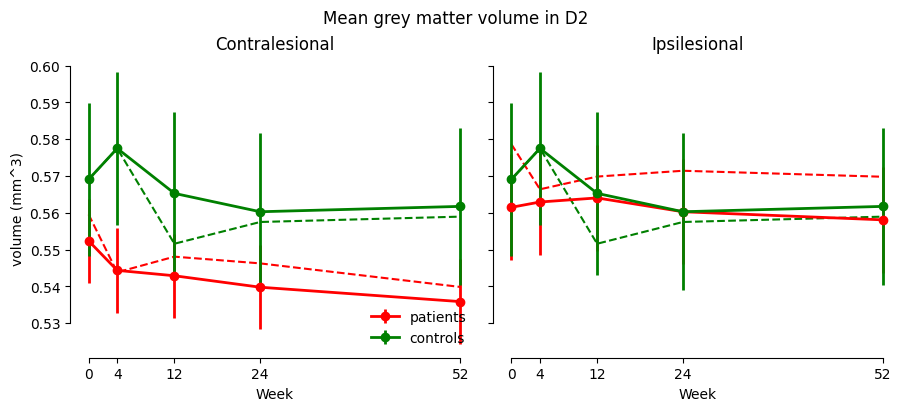

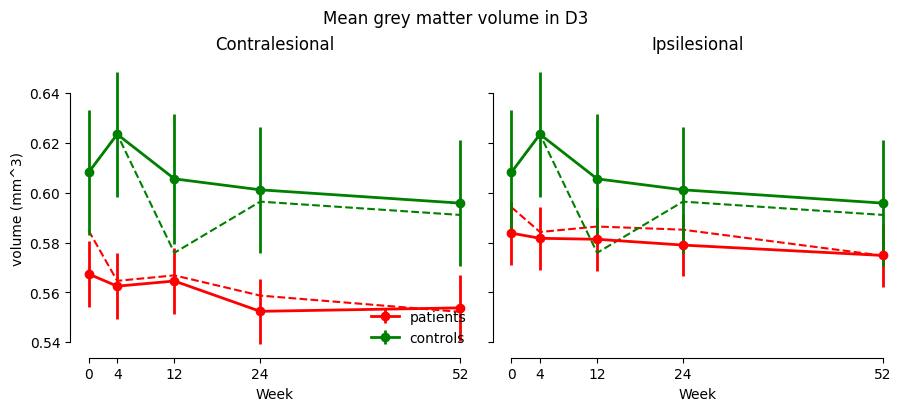

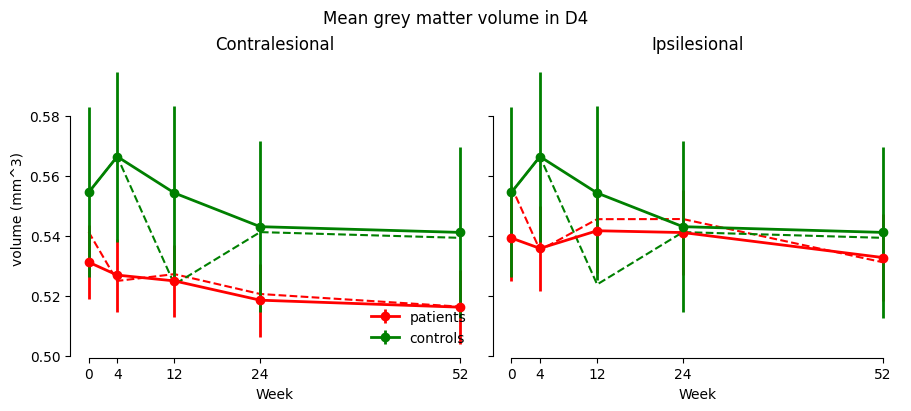

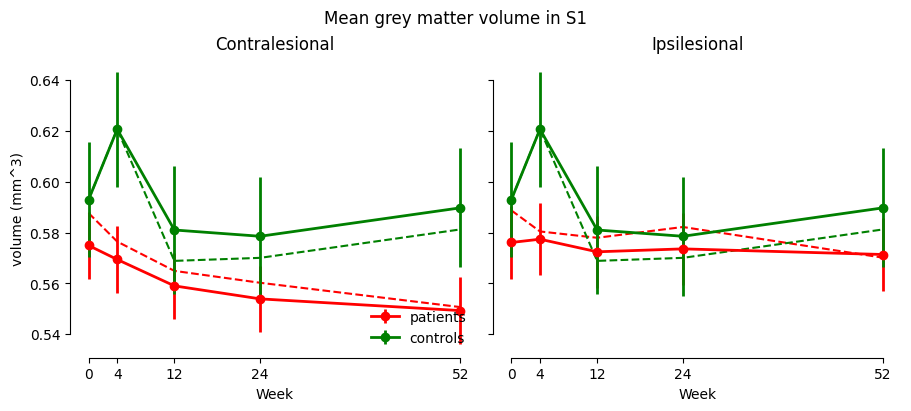

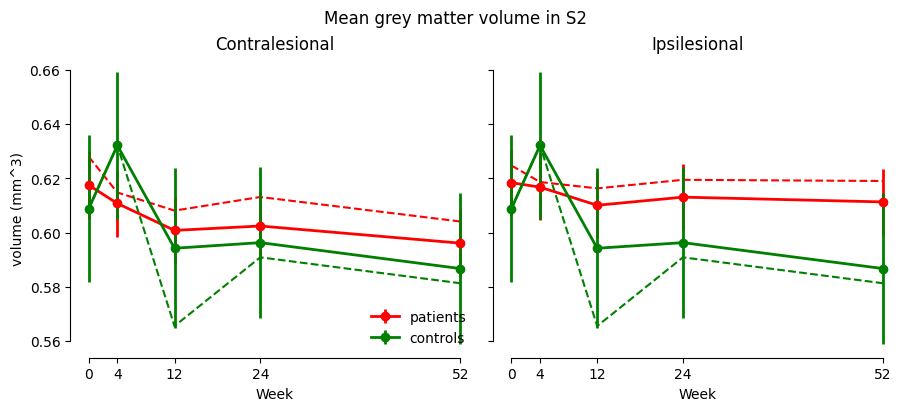

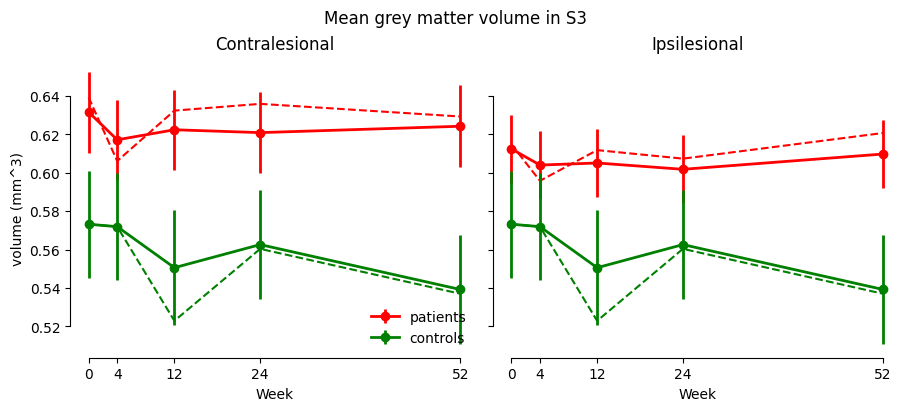

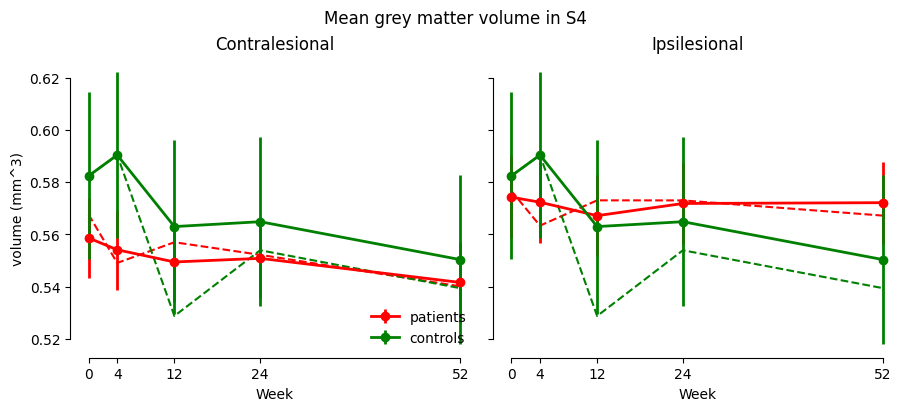

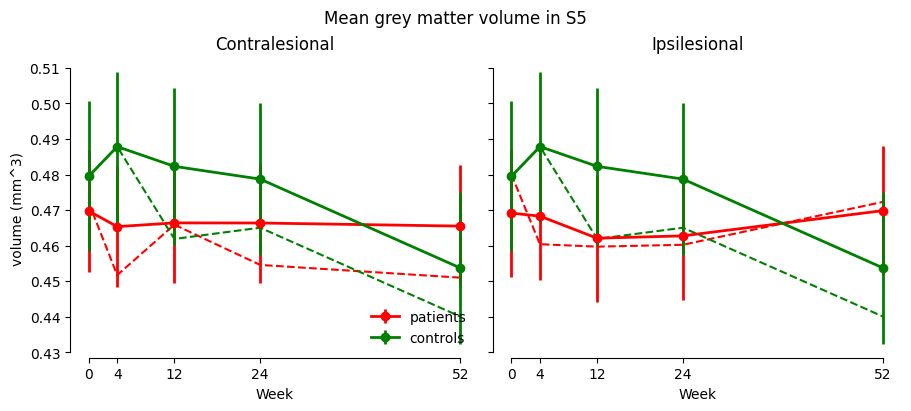

In [19]:
for r, roi in enumerate(rois):
    patients_lme_roi = patients_lme[patients_lme.regionname.str.contains(roi)].sort_values('Week')
    patients_actual_roi = patients_actual[patients_actual.regionname.str.contains(roi)].sort_values('Week')
    controls_lme_roi = controls_lme[controls_lme.regionname.str.contains(roi)].sort_values('Week')
    controls_actual_roi = controls_actual[controls_actual.regionname.str.contains(roi)].sort_values('Week')

    controls_lme_roi = controls_lme_roi.groupby(['Week']).agg({'beta': 'mean', 'se': 'mean'}).reset_index()
    controls_actual_roi = controls_actual_roi.groupby(['Week']).agg({'mean': 'mean'}).reset_index()

    fig, axs = plt.subplots(1, 2, figsize=(9,4), sharey = True, constrained_layout = True)

    for i, H in enumerate(gl.Hem):
        ax = axs[i]

        patients_lme_roi_h    = patients_lme_roi[patients_lme_roi.hemisphere == H].sort_values('Week')
        patients_actual_roi_h = patients_actual_roi[patients_actual_roi.hemisphere == H].sort_values('Week')


        ax.errorbar(x=patients_lme_roi_h['Week'], y=patients_lme_roi_h['beta'], yerr = patients_lme_roi_h['se'], fmt = '-o', color = 'red', linewidth = 2, label = 'patients')
        ax.plot(patients_actual_roi_h['Week'], patients_actual_roi_h['mean'], color ='red', linestyle = '--')

        ax.errorbar(x=controls_lme_roi['Week'], y=controls_lme_roi['beta'], yerr = controls_lme_roi['se'], fmt = '-o', color = 'green', linewidth = 2, label = 'controls')
        ax.plot(controls_actual_roi['Week'], controls_actual_roi['mean'], color = 'green', linestyle = '--',)

        ax.set_title("Contralesional" if H == 'l' else "Ipsilesional")
        ax.legend(loc = 'lower right', frameon = False) if i == 0 else None

    for i in range(2):
        axs[i].set_xticks(gl.weeks)
        axs[i].set_xlabel("Week")
        axs[i].set_title(gl.side[i])

    axs[0].set_ylabel('volume (mm^3)')

    fig.suptitle(f'Mean grey matter volume in {roi}')
    sns.despine(trim = True)

    fig.savefig(f'figure/lme_{roi}.pdf')

    plt.show()


In [20]:


# # bilateral controls (take mean of both hemispheres)
# controls_lme = controls_lme.groupby(['Week']).agg({'beta': 'mean', 'se': 'mean'}).reset_index()
# controls_actual = controls_actual.groupby(['Week']).agg({'mean': 'mean'}).reset_index()

# controls_lme = controls_lme.sort_values('Week')
# controls_actual = controls_actual.sort_values('Week')

In [21]:
# try this on the observed means - test is W0 is significantly different between regions

from scipy import stats
import numpy as np

rois = ['M1', 'M2', 'M3', 'M4']
week = 0

obs_means = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
obs_means = obs_means[(obs_means.isPatient ==1) & (obs_means.Week == week)]

for roi in rois:
    patients_l_df = obs_means[(obs_means.regionname == roi + 'L')]
    patients_r_df = obs_means[(obs_means.regionname == roi + 'R')]
    patients_lr_df = patients_l_df.merge(patients_r_df, on = 'subj_id', suffixes = ('_L', '_R'))

    patients_l = np.array(patients_lr_df['mean_L'])
    patients_r = np.array(patients_lr_df['mean_R'])

    t_val, p_val = stats.ttest_rel(patients_l, patients_r)
    print(f'**t-test for GM in {roi}L vs {roi}R at week {week}** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

**t-test for GM in M1L vs M1R at week 0** 
 t-value: -1.0275019193682025 	 p-value: 0.313301827032647


**t-test for GM in M2L vs M2R at week 0** 
 t-value: -1.0049255128068335 	 p-value: 0.32385447154103975


**t-test for GM in M3L vs M3R at week 0** 
 t-value: -0.7244406207038472 	 p-value: 0.47502656945826227


**t-test for GM in M4L vs M4R at week 0** 
 t-value: 1.186321035123144 	 p-value: 0.24583011176536013




In [22]:
# ALL WEEKS

from scipy import stats
import numpy as np

rois = ['M1', 'M2', 'M3', 'M4',
        'A1', 'A2', 'A3', 
        'D1', 'D2', 'D3', 'D4', 
        'S1', 'S2', 'S3', 'S4', 'S5']

for week in gl.weeks:
    obs_means = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
    obs_means = obs_means[(obs_means.isPatient ==1) & (obs_means.Week == week)]

    for roi in rois:
        patients_l_df = obs_means[(obs_means.regionname == roi + 'L')]
        patients_r_df = obs_means[(obs_means.regionname == roi + 'R')]
        patients_lr_df = patients_l_df.merge(patients_r_df, on = 'subj_id', suffixes = ('_L', '_R'))

        patients_l = np.array(patients_lr_df['mean_L'])
        patients_r = np.array(patients_lr_df['mean_R'])

        t_val, p_val = stats.ttest_rel(patients_l, patients_r)
        if p_val < .05:
            print(f'**t-test for GM in {roi}L vs {roi}R at week {week}** \n t-value: {t_val} \t p-value: {p_val}')
            print('\n')

**t-test for GM in D2L vs D2R at week 4** 
 t-value: -2.8934812722786143 	 p-value: 0.007032706092339925


**t-test for GM in D3L vs D3R at week 4** 
 t-value: -2.6956572466085005 	 p-value: 0.011403016625160415


**t-test for GM in M2L vs M2R at week 12** 
 t-value: -2.3357400008345883 	 p-value: 0.025730682726977597


**t-test for GM in M3L vs M3R at week 12** 
 t-value: -2.375125322410656 	 p-value: 0.023508489534275204


**t-test for GM in A2L vs A2R at week 12** 
 t-value: -2.482745443437663 	 p-value: 0.018296472859757603


**t-test for GM in D2L vs D2R at week 12** 
 t-value: -2.5223574407759983 	 p-value: 0.016660952198381755


**t-test for GM in D3L vs D3R at week 12** 
 t-value: -2.790806240622088 	 p-value: 0.00867145521041772


**t-test for GM in D4L vs D4R at week 12** 
 t-value: -2.1644838037000125 	 p-value: 0.03776091627145531


**t-test for GM in M2L vs M2R at week 24** 
 t-value: -2.3784453967135835 	 p-value: 0.023731041454136008


**t-test for GM in M3L vs M3R at we